In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
IMAGE_H = 256
IMAGE_W = 256
BATCH_SIZE = 32
channels = 3
epochs= 50
SEED = 123

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define subdirectories
base_dir = '/content/drive/MyDrive/datasets/datasets/original_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [ ]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    shuffle=False,  # Typically you don't shuffle test data
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE
)


Found 486 files belonging to 2 classes.
Found 104 files belonging to 2 classes.
Found 106 files belonging to 2 classes.


In [ ]:
# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# count the images in each set
def count_images(dataset_path):
    return sum([len(files) for _, _, files in os.walk(dataset_path)])

print(f"Training images: {count_images(train_dir)}")
print(f"Validation images: {count_images(val_dir)}")
print(f"Test images: {count_images(test_dir)}")

Training images: 486
Validation images: 104
Test images: 106


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

In [ ]:
IMAGE_SIZE = [256, 256]
densenet = DenseNet121(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Freeze all layers
for layer in densenet.layers:
    layer.trainable = False

In [ ]:
x = Flatten()(densenet.output)
classification = Dense(1, activation='sigmoid')(x)

In [ ]:
model = Model(inputs=densenet.input, outputs=classification)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

 Total params: 7,103,041 (27.10 MB)

 Trainable params: 65,537 (256.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [ ]:
history=model.fit(
    train_dataset,
    epochs=epochs,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_dataset,
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6588 - loss: 1.4743 - val_accuracy: 0.6346 - val_loss: 1.1345
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7146 - loss: 0.7316 - val_accuracy: 0.7308 - val_loss: 1.1176
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8267 - loss: 0.4859 - val_accuracy: 0.6923 - val_loss: 0.9300
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8532 - loss: 0.3868 - val_accuracy: 0.7212 - val_loss: 0.9839
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8941 - loss: 0.2711 - val_accuracy: 0.6538 - val_loss: 0.9574
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9127 - loss: 0.2256 - val_accuracy: 0.7212 - val_loss: 1.1993
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9100 - loss: 0.2135 - val_accuracy: 0.6731 - val_loss: 0.8910
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9223 - loss: 0.1760 - val_accuracy: 0.7500 - va

In [ ]:
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.7588 - loss: 0.9843


[0.9460327625274658, 0.7641509175300598]

In [ ]:
acc= history.history['accuracy']
val_acc = history.history['val_accuracy']

loss= history.history['loss']
val_loss = history.history['val_loss']

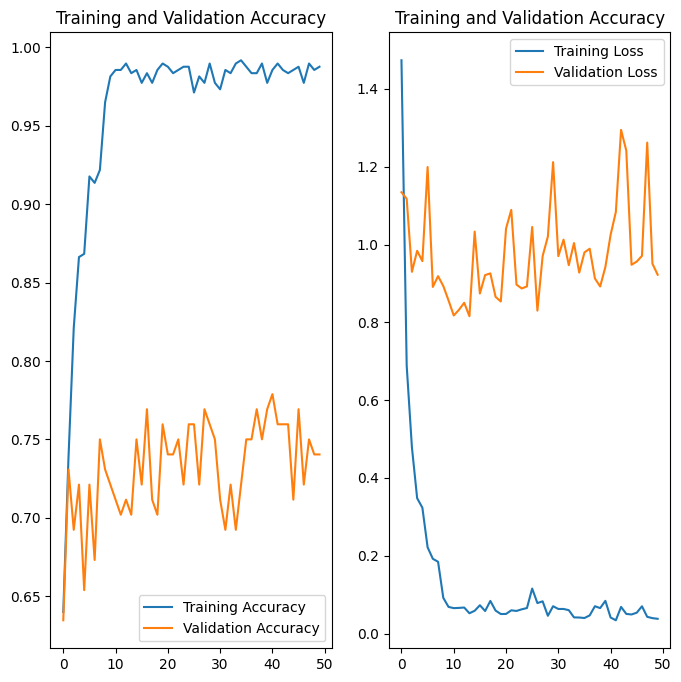

In [ ]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Accuracy')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Class names
class_names = sorted(os.listdir(test_dir))

# Prepare data
test_images = []
test_labels = []
for images, labels in test_dataset:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())
test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)

# Predictions
y_pred_probs = model.predict(test_images).flatten()  # output of sigmoid, shape = (num_samples,)
y_pred = (y_pred_probs >= 0.5).astype(int)  # Thresholding at 0.5


4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step


In [ ]:
# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(test_labels, y_pred, target_names=class_names))

Confusion Matrix:
 [[24  7]
 [18 57]]
Classification Report:
                                                   precision    recall  f1-score   support

400x Normal Oral Cavity Histopathological Images       0.57      0.77      0.66        31
              400x OSCC Histopathological Images       0.89      0.76      0.82        75

                                        accuracy                           0.76       106
                                       macro avg       0.73      0.77      0.74       106
                                    weighted avg       0.80      0.76      0.77       106



In [ ]:
# Overall metrics
precision = precision_score(test_labels, y_pred, average='macro')
recall = recall_score(test_labels, y_pred, average='macro')
f1 = f1_score(test_labels, y_pred, average='macro')

# Specificity (custom)
TN = np.zeros(len(class_names))
FP = np.zeros(len(class_names))
for i in range(len(class_names)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP[i] = np.sum(cm[:, i]) - TP
    TN[i] = np.sum(cm) - (TP + FP[i] + FN)
specificity = np.mean(TN / (TN + FP))

# Display
print(f"\nOverall Precision (macro):  {precision:.4f}")
print(f"Overall Recall (macro):     {recall:.4f}")
print(f"Overall Specificity (macro):{specificity:.4f}")
print(f"Overall F1 Score (macro):   {f1:.4f}")


Overall Precision (macro):  0.7310
Overall Recall (macro):     0.7671
Overall Specificity (macro):0.7671
Overall F1 Score (macro):   0.7388


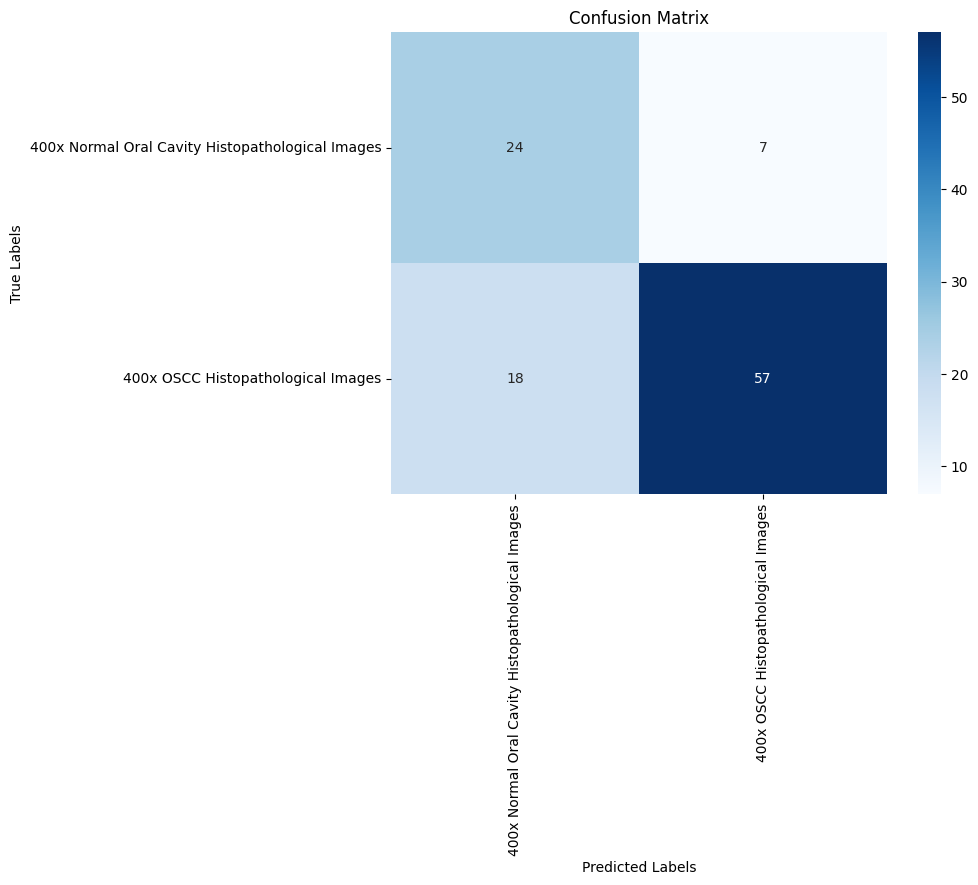

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
AUC Score: 0.8232


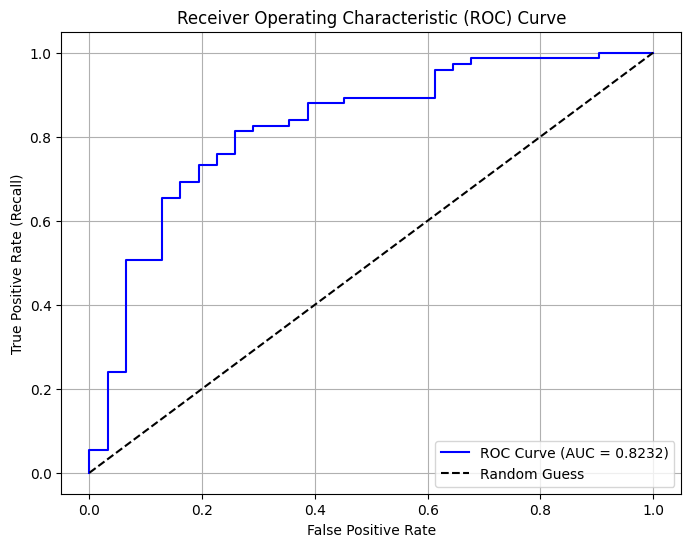

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# Collect true labels and predicted scores
y_true = []
y_scores = []

for images, labels in test_dataset:
    preds = model.predict(images)

    # If your model has a sigmoid output for binary classification:
    if preds.shape[1] == 1 or len(preds.shape) == 1:
        preds = preds.flatten()
    else:
        preds = preds[:, 1]  # Use the probability of class 1 in softmax

    y_true.extend(labels.numpy())
    y_scores.extend(preds)

y_true = np.array(y_true)
y_scores = np.array(y_scores)

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc_score = roc_auc_score(y_true, y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})", color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
